# team4d - trend analysis notebook (part 2)

This notebook is organized as a **workflow scaffold** for identifying likely long-term drivers and responses between meteorological conditions and estuary water conditions.

## Why this structure?
- Hourly data over ~30 years is rich, but can be noisy and strongly seasonal.
- If we test relationships on raw series too early, shared day/season cycles can look like false causal signal.
- A better process is: quality checks -> separate timescales -> test lead/lag hypotheses -> fit interpretable response models -> validate predictively.

## What you should expect here
- Each section has short runnable code stubs.
- Most cells include comments on *what* to do, *how* to do it, and *why* the step matters.
- You can replace placeholders with your preferred variables/models as your story sharpens.


In [11]:
# basic tools for paths and tables
# presently running on python 3.13.* in a venv
from pathlib import Path
import warnings

import numpy as np                  # arrays, math, and quick numeric helpers
import pandas as pd                 # dataframe tools and time-series handling
import matplotlib.pyplot as plt     # primary plotting
import seaborn as sns               # readable defaults for EDA charts

# keep charts and table output readable by default
sns.set_theme( style = 'whitegrid' )
plt.rcParams[ 'figure.figsize' ] = ( 12, 5 )
pd.set_option( 'display.max_columns', 200 )

# optional statsmodels imports (used later for decomposition and lag tests)
# if these fail, install statsmodels in your project venv and re-run
try:
    from statsmodels.tsa.seasonal import STL
    from statsmodels.tsa.stattools import ccf, grangercausalitytests

except ImportError:
    STL = None
    ccf = None
    grangercausalitytests = None
    warnings.warn( 'statsmodels is not installed; decomposition and lag-test stubs will be skipped.' )


In [12]:
# load the long-term hourly trend table
data_path = Path( '../Data/Team4D/team4d.baseline.1h_trend_records.csv' )

water = pd.read_csv( 
    data_path,
    parse_dates = [ 'datetime' ],
)

# always sort explicitly for time-series work
water = water.sort_values( 'datetime' ).reset_index( drop = True )

print( f'rows: {len( water ):,}' )
print( f'date span: {water[ "datetime" ].min()} to {water[ "datetime" ].max()}' )
water.head( 3 )


/var/folders/fr/4m_77r353cs6l44l0mrx2cr00000gn/T/ipykernel_22643/487300839.py:4: DtypeWarning: Columns (0: station) have mixed types. Specify dtype option on import or set low_memory=False.
  water = pd.read_csv(


rows: 5,647,164
date span: 1995-03-03 18:00:00 to 2025-12-31 23:00:00


,region,station,datetime,w_temp_c,w_sal_psu,w_do_mg_l,w_do_pct,depth_m,w_ph,m_wind_ms,m_ssrd_kwh_m2,m_precip_mmh,m_temp_c
0,ace,bb,1995-03-03 18:00:00,14.2,17.6,9.0,97.8,0.91,8.0,5.574228,0.778596,0.0,15.15426
1,ace,sp,1995-03-03 18:00:00,14.1,10.0,8.8,91.2,0.63,7.7,5.574228,0.778596,0.0,15.15426
2,ace,sp,1995-03-03 19:00:00,13.8,13.6,8.6,90.5,1.20,7.9,5.791434,0.696160,0.0,15.07460


## 0) Frame the Driver-Response Question

Before model code, write down candidate mechanisms.

### Example hypotheses
- Changes in `m_temp_c` (air temperature) lead changes in `w_temp_c` (water temperature) with short lag windows (hours to days).
- Wind and radiation may alter mixing/heating, affecting dissolved oxygen and salinity with different lag shapes.
- Precipitation may influence salinity and dissolved oxygen through runoff/freshwater effects at medium lags.

### Why this matters
- Declared hypotheses protect you from accidental fishing across dozens of variables/lags.
- You can still explore, but with a clear record of what was pre-specified vs discovered.


In [13]:
# quick variable inventory for planning
all_cols = water.columns.tolist( )

met_candidate_cols = [ col for col in all_cols if col.startswith( 'm_' ) ]
water_candidate_cols = [ col for col in all_cols if col.startswith( 'w_' ) ]

print( 'meteorological candidates:' )
print( met_candidate_cols )
print( '' )
print( 'water-response candidates:' )
print( water_candidate_cols )


meteorological candidates:
['m_wind_ms', 'm_ssrd_kwh_m2', 'm_precip_mmh', 'm_temp_c']

water-response candidates:
['w_temp_c', 'w_sal_psu', 'w_do_mg_l', 'w_do_pct', 'w_ph']


## 1) Data Quality + Coverage Checks

### What
Confirm temporal continuity, missingness, and obvious outliers/units before inference.

### How
- Verify timestamps are unique and hourly.
- Quantify missingness per variable.
- Inspect suspicious ranges (domain sanity checks).

### Why
- Time-series lag models are sensitive to gaps and irregular spacing.
- Silent QC issues can produce false lead/lag structure.


In [14]:
# 1a) timestamp integrity
print( f'unique timestamps: {water[ "datetime" ].nunique():,}' )
print( f'total records:      {len( water ):,}' )

# check duplicate timestamps
dupe_count = water.duplicated( subset = [ 'datetime' ] ).sum( )
print( f'duplicate datetimes: {dupe_count:,}' )

# check interval consistency (in hours)
delta_hours = water[ 'datetime' ].diff( ).dt.total_seconds( ).div( 3600 )
print( '' )
print( 'interval hour-counts ( top 10 ):' )
print( delta_hours.value_counts( dropna = False ).head( 10 ) )

# 1b) missingness
missing_pct = water.isna( ).mean( ).mul( 100 ).sort_values( ascending = False )
missing_pct.to_frame( 'missing_pct' ).head( 20 )


unique timestamps: 265,013
total records:      5,647,164
duplicate datetimes: 5,382,151

interval hour-counts ( top 10 ):
datetime
0.0     5382151
1.0      264627
2.0          68
3.0          45
4.0          37
5.0          21
7.0          19
6.0          19
8.0          16
11.0         16
Name: count, dtype: int64


,missing_pct
region,0.0
station,0.0
datetime,0.0
w_temp_c,0.0
w_sal_psu,0.0
w_do_mg_l,0.0
w_do_pct,0.0
depth_m,0.0
w_ph,0.0
m_wind_ms,0.0


## 2) Build Multiple Time Scales (Hourly, Daily, Weekly)

### What
Create aligned datasets at different resolutions.

### How
- Keep hourly data for diurnal dynamics and short-lag behavior.
- Build daily/weekly aggregates for long-term driver screening.

### Why
- Long-term relationships are often clearer at coarser resolution.
- If a signal only exists at one resolution, interpretation is weaker.


In [ ]:
# move to datetime index for resampling
water_ts = water.set_index( 'datetime' ).sort_index( )

hourly = water_ts.copy( )
daily = water_ts.resample( 'D' ).mean( numeric_only = True )
weekly = water_ts.resample( 'W' ).mean( numeric_only = True )

print( 'hourly shape:', hourly.shape )
print( 'daily shape: ', daily.shape )
print( 'weekly shape:', weekly.shape )

# coverage check at each scale
summary = pd.DataFrame( { 
    'start': [ hourly.index.min( ), daily.index.min( ), weekly.index.min( ) ],
    'end': [ hourly.index.max( ), daily.index.max( ), weekly.index.max( ) ],
    'rows': [ len( hourly ), len( daily ), len( weekly ) ],
}, index = [ 'hourly', 'daily', 'weekly' ] )
summary


hourly shape: (5647164, 12)
daily shape:  (11262, 10)
weekly shape: (1610, 10)


,start,end,rows
hourly,1995-03-03 18:00:00,2025-12-31 23:00:00,5647164
daily,1995-03-03 00:00:00,2025-12-31 00:00:00,11262
weekly,1995-03-05 00:00:00,2026-01-04 00:00:00,1610


## 3) Separate Trend / Seasonality / Residual (Decomposition)

### What
Decompose key response variables so recurring cycles do not masquerade as causal driver effects.

### How
- Start with daily scale for tractable seasonal decomposition.
- Use STL to estimate trend + seasonal + remainder for candidate response series.

### Why
- Shared annual cycles between air and water temperature are expected and not enough for driver claims.
- Driver-response evidence should survive after accounting for recurring seasonality.


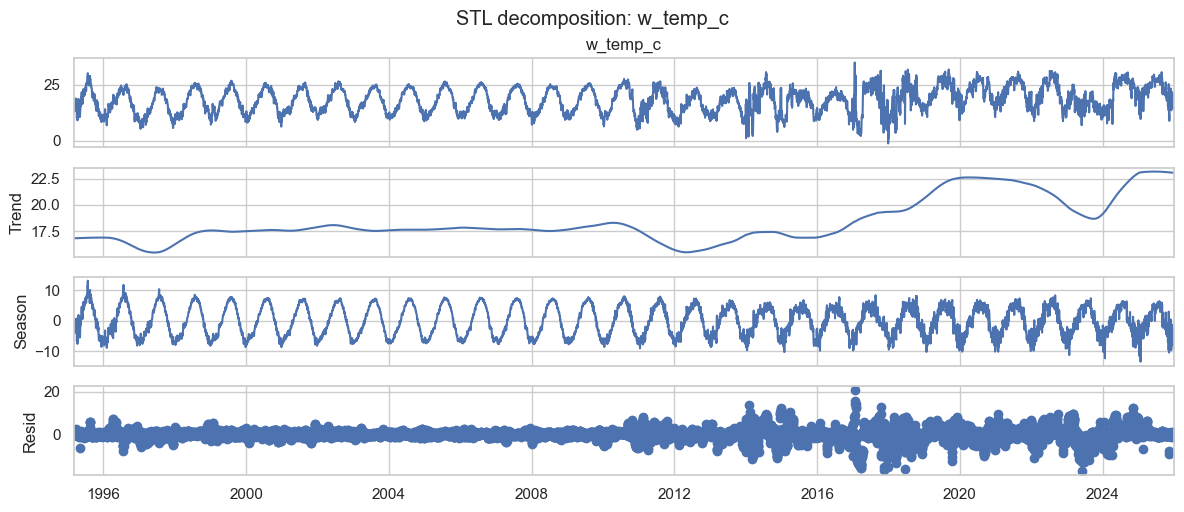

In [16]:
# choose a first response variable and run STL on daily data
response_col = 'w_temp_c'

if STL is None:
    print( 'Skipping STL: statsmodels is unavailable in this environment.' )

elif response_col not in daily.columns:
    print( f'Skipping STL: {response_col} is not in daily columns.' )

else:
    # yearly seasonality on daily data -> period ~ 365
    response_series = daily[ response_col ].dropna( )
    stl_fit = STL( response_series, period = 365, robust = True ).fit( )

    fig = stl_fit.plot( )
    fig.suptitle( f'STL decomposition: {response_col}', y = 1.02 )
    plt.show( )

    # keep components for downstream tests
    decomp_df = pd.DataFrame( { 
        'observed': stl_fit.observed,
        'trend': stl_fit.trend,
        'seasonal': stl_fit.seasonal,
        'resid': stl_fit.resid,
    } )
    decomp_df.head( 3 )


### Interpretation Notes (Current STL Result)

Current reading of the STL plot for `w_temp_c` is:

- `trend`: roughly flat from about 1995 to ~2011, then generally higher afterward.
- `seasonal`: the yearly cycle remains visible, but appears less smooth in later years.
- `resid`: variance looks much larger after ~2012.

Important caution before over-interpreting this as purely environmental change:

- The network/data coverage shifts over time (number of records and active stations per day changes substantially).
- When coverage drops, daily averages become noisier, and STL residuals can look more erratic even without a true regime shift.

Working interpretation:

- A long-term warming signal is plausible.
- The post-2012 increase in jaggedness/erratic residual behavior is likely a mix of real signal and sampling/composition effects.
- Next step is a coverage-aware, station-balanced decomposition to test how much of this pattern persists after controlling sampling structure.


raw daily points: 11,181
balanced filtered points (min_stations=8): 8,269

station_count quantiles (all days):
0.10     5.0
0.25     7.0
0.50    13.0
0.75    39.0
0.90    50.0
Name: station_count, dtype: float64


,resid_std_pre_2012,resid_std_post_2012,post_over_pre_ratio
raw_daily,1.309386,3.433478,2.622204
station_balanced_filtered,1.617158,5.230810,3.234570


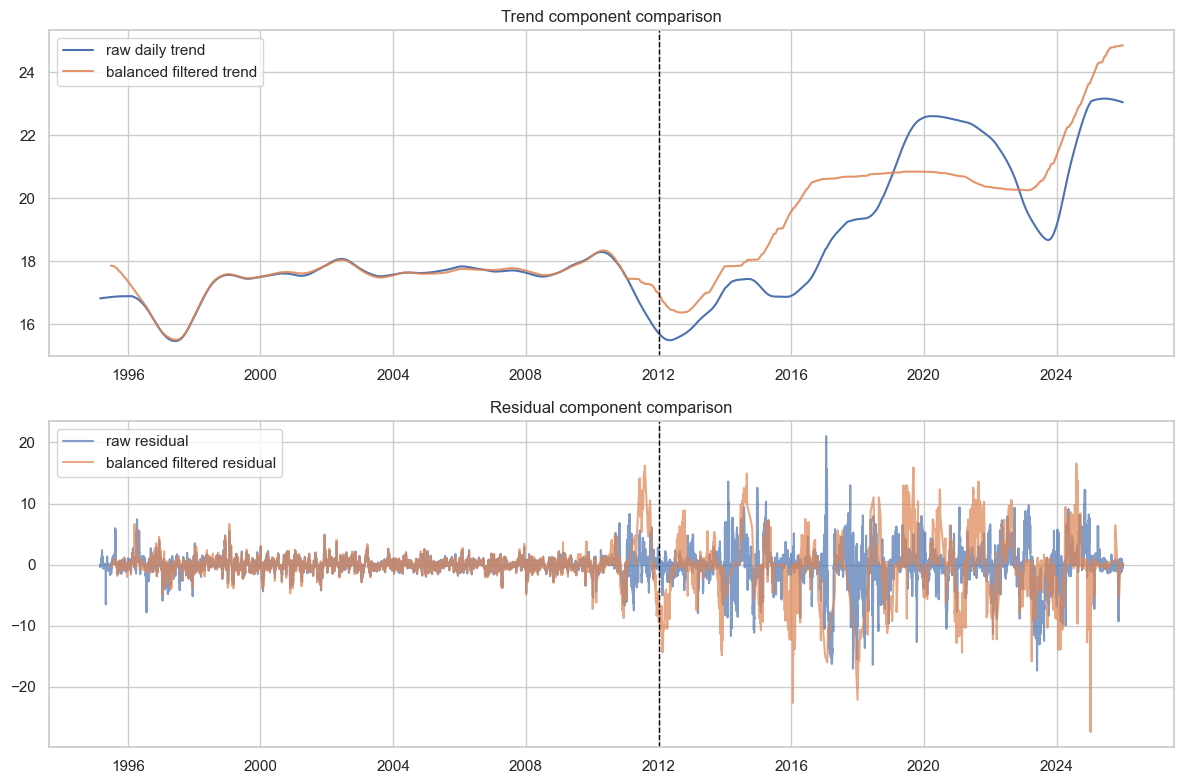

In [17]:
# coverage-aware STL check: compare raw daily mean vs station-balanced daily mean
# this helps separate environmental signal from sampling/coverage artifacts
if STL is None:
    print( 'Skipping coverage-aware STL check: statsmodels is unavailable in this environment.' )

elif 'w_temp_c' not in water.columns:
    print( 'Skipping coverage-aware STL check: w_temp_c is missing from the dataset.' )

else:
    # 1) build per-station daily means, then equally weight stations each day
    station_day = ( 
        water.assign( date = water[ 'datetime' ].dt.floor( 'D' ) )
        .groupby( [ 'date', 'station' ], dropna = False )[ 'w_temp_c' ]
        .mean( )
        .reset_index( )
    )

    station_count = station_day.groupby( 'date' )[ 'station' ].nunique( )
    balanced_daily = station_day.groupby( 'date' )[ 'w_temp_c' ].mean( )

    balanced_df = pd.concat( [ balanced_daily, station_count ], axis = 1 )
    balanced_df.columns = [ 'w_temp_c_balanced', 'station_count' ]
    balanced_df = balanced_df.sort_index( )

    # 2) apply a minimum station-count filter to reduce unstable daily averages
    min_stations = 8
    filtered_balanced = balanced_df.loc[ 
        balanced_df[ 'station_count' ] >= min_stations,
        'w_temp_c_balanced',
    ].dropna( )

    # raw daily series used in the earlier STL cell
    raw_daily = daily[ 'w_temp_c' ].dropna( )

    print( f'raw daily points: {len( raw_daily ):,}' )
    print( f'balanced filtered points (min_stations={min_stations}): {len( filtered_balanced ):,}' )
    print( '' )
    print( 'station_count quantiles (all days):' )
    print( balanced_df[ 'station_count' ].quantile( [ 0.1, 0.25, 0.5, 0.75, 0.9 ] ) )

    # 3) run STL on both series (annual seasonality at daily resolution)
    raw_fit = STL( raw_daily, period = 365, robust = True ).fit( )
    bal_fit = STL( filtered_balanced, period = 365, robust = True ).fit( )

    raw_comp = pd.DataFrame( { 
        'observed': raw_fit.observed,
        'trend': raw_fit.trend,
        'seasonal': raw_fit.seasonal,
        'resid': raw_fit.resid,
    } )

    bal_comp = pd.DataFrame( { 
        'observed': bal_fit.observed,
        'trend': bal_fit.trend,
        'seasonal': bal_fit.seasonal,
        'resid': bal_fit.resid,
    } )

    split_date = pd.Timestamp( '2012-01-01' )

    raw_pre = raw_comp.loc[ raw_comp.index < split_date, 'resid' ]
    raw_post = raw_comp.loc[ raw_comp.index >= split_date, 'resid' ]
    bal_pre = bal_comp.loc[ bal_comp.index < split_date, 'resid' ]
    bal_post = bal_comp.loc[ bal_comp.index >= split_date, 'resid' ]

    compare_table = pd.DataFrame( { 
        'resid_std_pre_2012': [ raw_pre.std( ), bal_pre.std( ) ],
        'resid_std_post_2012': [ raw_post.std( ), bal_post.std( ) ],
        'post_over_pre_ratio': [ raw_post.std( ) / raw_pre.std( ), bal_post.std( ) / bal_pre.std( ) ],
    }, index = [ 'raw_daily', 'station_balanced_filtered' ] )

    display( compare_table )

    # 4) visual comparison of trend and residual components
    fig, axes = plt.subplots( 2, 1, figsize = ( 12, 8 ), sharex = False )

    axes[ 0 ].plot( raw_comp.index, raw_comp[ 'trend' ], label = 'raw daily trend' )
    axes[ 0 ].plot( bal_comp.index, bal_comp[ 'trend' ], label = 'balanced filtered trend', alpha = 0.85 )
    axes[ 0 ].axvline( split_date, color = 'black', linestyle = '--', linewidth = 1 )
    axes[ 0 ].set_title( 'Trend component comparison' )
    axes[ 0 ].legend( )

    axes[ 1 ].plot( raw_comp.index, raw_comp[ 'resid' ], label = 'raw residual', alpha = 0.7 )
    axes[ 1 ].plot( bal_comp.index, bal_comp[ 'resid' ], label = 'balanced filtered residual', alpha = 0.7 )
    axes[ 1 ].axvline( split_date, color = 'black', linestyle = '--', linewidth = 1 )
    axes[ 1 ].set_title( 'Residual component comparison' )
    axes[ 1 ].legend( )

    plt.tight_layout( )
    plt.show( )


### 3b) Thermal Category Grouping (Cold / Mid / Warm)

Yes, we can pre-categorize regions by baseline water temperature and analyze behavior within those categories.

Approach used below:
- Compute each region's long-run mean `w_temp_c` (regional climatology).
- Split regions into three groups (`cold`, `mid`, `warm`) using tertiles.
- Build daily series by thermal category using equal regional weighting per day.
- Run STL within each category to compare trends and residual variability.

Why this helps:
- Reduces direct mixing of naturally warm and naturally cold regions in one pooled national series.
- Makes it easier to ask whether *similar-baseline* regions show similar trend/residual behavior.

Caution:
- Categories are based on the current sample and can shift if region coverage changes.
- Category analysis complements, but does not replace, explicit region-level modeling.


In [ ]:
# thermal-category decomposition: cold / mid / warm
# goal: reduce direct warm-vs-cold regional mixing in pooled trend/residual interpretation
if STL is None:
    print( 'Skipping thermal-category STL: statsmodels is unavailable in this environment.' )

elif not { 'region', 'datetime', 'w_temp_c' }.issubset( water.columns ):
    print( 'Skipping thermal-category STL: required columns are missing.' )

else:
    # 1) classify regions into tertiles using long-run regional mean temperature
    region_clim = water.groupby( 'region' )[ 'w_temp_c' ].mean( ).dropna( ).sort_values( )

    if len( region_clim ) < 3:
        print( 'Not enough regions to create cold/mid/warm categories.' )

    else:
        thermal_labels = [ 'cold', 'mid', 'warm' ]
        region_group = pd.qcut( region_clim, q = 3, labels = thermal_labels )

        region_group_df = pd.DataFrame( { 
            'region_mean_w_temp_c': region_clim,
            'thermal_group': region_group.astype( str ),
        } )

        print( 'Region-to-thermal-group mapping:' )
        display( region_group_df )

        # 2) daily regional means, then equal-weight aggregate within each thermal group
        region_day = ( 
            water.assign( date = water[ 'datetime' ].dt.floor( 'D' ) )
            .groupby( [ 'date', 'region' ], dropna = False )[ 'w_temp_c' ]
            .mean( )
            .reset_index( )
        )

        region_day = region_day.merge( 
            region_group_df[ [ 'thermal_group' ] ],
            left_on = 'region',
            right_index = True,
            how = 'inner',
        )

        # absolute category daily mean (equal regional weight)
        cat_daily = ( 
            region_day.groupby( [ 'date', 'thermal_group' ] )[ 'w_temp_c' ]
            .mean( )
            .unstack( 'thermal_group' )
            .sort_index( )
        )

        # anomaly category daily mean (remove each region baseline first)
        region_day = region_day.merge( 
            region_clim.rename( 'region_mean_w_temp_c' ),
            left_on = 'region',
            right_index = True,
            how = 'left',
        )
        region_day[ 'w_temp_anom' ] = region_day[ 'w_temp_c' ] - region_day[ 'region_mean_w_temp_c' ]

        cat_daily_anom = ( 
            region_day.groupby( [ 'date', 'thermal_group' ] )[ 'w_temp_anom' ]
            .mean( )
            .unstack( 'thermal_group' )
            .sort_index( )
        )

        # 3) STL by thermal category + summary table
        split_date = pd.Timestamp( '2012-01-01' )
        min_points = 365 * 5

        summary_rows = [ ]
        fig, axes = plt.subplots( 3, 2, figsize = ( 14, 12 ), sharex = False )

        for row_idx, group_name in enumerate( thermal_labels ):
            if group_name not in cat_daily.columns or group_name not in cat_daily_anom.columns:
                continue

            s_abs = cat_daily[ group_name ].dropna( )
            s_anom = cat_daily_anom[ group_name ].dropna( )

            if len( s_abs ) < min_points or len( s_anom ) < min_points:
                print( f'Skipping {group_name}: not enough daily points for stable STL.' )
                continue

            fit_abs = STL( s_abs, period = 365, robust = True ).fit( )
            fit_anom = STL( s_anom, period = 365, robust = True ).fit( )

            comp_abs = pd.DataFrame( { 
                'trend': fit_abs.trend,
                'resid': fit_abs.resid,
            }, index = s_abs.index )

            comp_anom = pd.DataFrame( { 
                'trend': fit_anom.trend,
                'resid': fit_anom.resid,
            }, index = s_anom.index )

            abs_pre = comp_abs.loc[ comp_abs.index < split_date, 'resid' ]
            abs_post = comp_abs.loc[ comp_abs.index >= split_date, 'resid' ]
            anom_pre = comp_anom.loc[ comp_anom.index < split_date, 'resid' ]
            anom_post = comp_anom.loc[ comp_anom.index >= split_date, 'resid' ]

            summary_rows.append( { 
                'thermal_group': group_name,
                'n_days_abs': len( s_abs ),
                'n_days_anom': len( s_anom ),
                'abs_resid_std_pre_2012': abs_pre.std( ),
                'abs_resid_std_post_2012': abs_post.std( ),
                'abs_post_over_pre': abs_post.std( ) / abs_pre.std( ),
                'anom_resid_std_pre_2012': anom_pre.std( ),
                'anom_resid_std_post_2012': anom_post.std( ),
                'anom_post_over_pre': anom_post.std( ) / anom_pre.std( ),
            } )

            axes[ row_idx, 0 ].plot( comp_abs.index, comp_abs[ 'trend' ] )
            axes[ row_idx, 0 ].axvline( split_date, color = 'black', linestyle = '--', linewidth = 1 )
            axes[ row_idx, 0 ].set_title( f'{group_name}: STL trend (absolute temp)' )

            axes[ row_idx, 1 ].plot( comp_anom.index, comp_anom[ 'resid' ] )
            axes[ row_idx, 1 ].axvline( split_date, color = 'black', linestyle = '--', linewidth = 1 )
            axes[ row_idx, 1 ].set_title( f'{group_name}: STL residual (region-centered anomaly)' )

        plt.tight_layout( )
        plt.show( )

        if summary_rows:
            summary_df = pd.DataFrame( summary_rows ).set_index( 'thermal_group' )
            print( 'Thermal-group STL summary:' )
            display( summary_df )

        else:
            print( 'No thermal groups produced enough data for STL summary.' )


## 4) Lead/Lag Exploration (Hypothesis Generation, Not Final Proof)

### What
Inspect whether candidate drivers lead responses at plausible lag windows.

### How
- Start with deseasonalized or differenced series.
- Compute cross-correlation over a constrained lag window.

### Why
- Raw correlation on seasonal series often overstates relationships.
- This step narrows down lag windows to test formally in models.


Top absolute correlations (exploratory):


,lag_h,corr
0,0,0.849223
1,1,-0.426775
84,84,-0.001514
83,83,0.001283
2,2,0.001154
18,18,-0.001110
48,48,0.001045
19,19,0.000955
105,105,0.000953
49,49,-0.000940


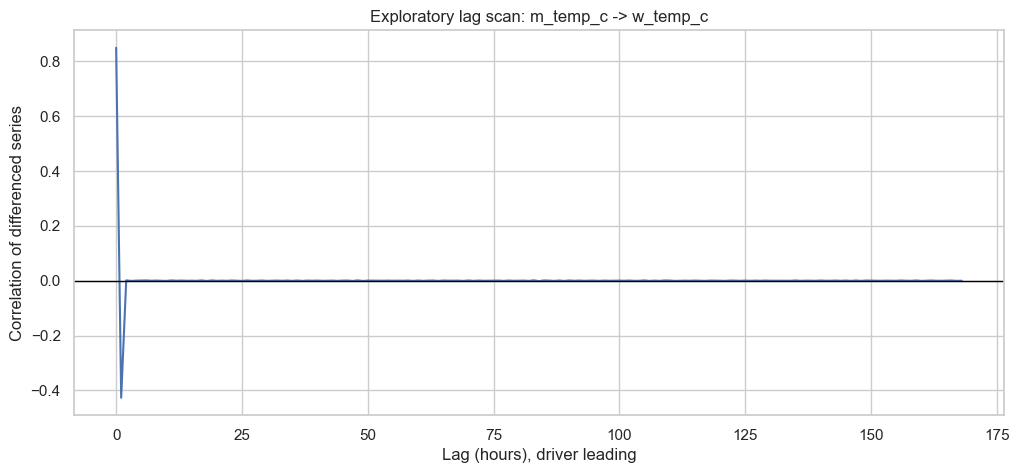

In [18]:
# simple lag scan helper using shifted correlations
# (kept explicit for teaching clarity; replace with a formal method later)
driver_col = 'm_temp_c'
response_col = 'w_temp_c'
max_lag_hours = 7 * 24

lag_scan = pd.DataFrame( )

if driver_col in hourly.columns and response_col in hourly.columns:
    pair_df = hourly[ [ driver_col, response_col ] ].dropna( ).copy( )

    # differencing reduces slow drift and shared trends before quick lag scan
    pair_df[ 'driver_diff' ] = pair_df[ driver_col ].diff( )
    pair_df[ 'response_diff' ] = pair_df[ response_col ].diff( )
    pair_df = pair_df.dropna( )

    rows = [ ]
    for lag in range( 0, max_lag_hours + 1 ):
        # lag > 0 means driver precedes response by `lag` hours
        corr_val = pair_df[ 'driver_diff' ].shift( lag ).corr( pair_df[ 'response_diff' ] )
        rows.append( { 'lag_h': lag, 'corr': corr_val } )

    lag_scan = pd.DataFrame( rows )

    top_hits = lag_scan.reindex( lag_scan[ 'corr' ].abs( ).sort_values( ascending = False ).index ).head( 10 )
    print( 'Top absolute correlations (exploratory):' )
    display( top_hits )

    sns.lineplot( data = lag_scan, x = 'lag_h', y = 'corr' )
    plt.title( f'Exploratory lag scan: {driver_col} -> {response_col}' )
    plt.xlabel( 'Lag (hours), driver leading' )
    plt.ylabel( 'Correlation of differenced series' )
    plt.axhline( 0, color = 'black', linewidth = 1 )
    plt.show( )

else:
    print( f'Skipping lag scan: ensure {driver_col} and {response_col} exist in hourly columns.' )


## 5) Formal Driver-Response Model Stubs

### What
Build interpretable models that include lagged drivers while controlling season/time structure.

### Good first options
- Distributed lag regression (easy to interpret).
- Transfer-function/ARIMAX style model (if strong autocorrelation remains).
- VAR + Granger tests for multivariate predictive-direction checks.

### Why
- Formal models estimate effect size and uncertainty, not just visual lag peaks.
- Controls reduce false positives from shared cycles.


In [19]:
# stub: construct lagged feature matrix for one driver-response pair
# this is setup only; you can plug into statsmodels/sklearn later
driver_col = 'm_temp_c'
response_col = 'w_temp_c'
lag_hours = [ 1, 3, 6, 12, 24, 48, 72, 96, 120, 168 ]

if driver_col in hourly.columns and response_col in hourly.columns:
    model_df = hourly[ [ response_col, driver_col ] ].copy( )

    for lag_h in lag_hours:
        feat_name = f'{driver_col}_lag_{lag_h}h'
        model_df[ feat_name ] = model_df[ driver_col ].shift( lag_h )

    # simple time controls: hour-of-day and day-of-year
    model_df[ 'hour' ] = model_df.index.hour
    model_df[ 'day_of_year' ] = model_df.index.dayofyear

    # TODO: optionally add harmonic terms for smooth seasonality
    # model_df[ 'sin_doy' ] = np.sin( 2 * np.pi * model_df[ 'day_of_year' ] / 365.25 )
    # model_df[ 'cos_doy' ] = np.cos( 2 * np.pi * model_df[ 'day_of_year' ] / 365.25 )

    model_df = model_df.dropna( )
    print( 'Model-ready rows:', len( model_df ) )
    model_df.head( 3 )

else:
    print( f'Skipping model setup: ensure {driver_col} and {response_col} exist in hourly columns.' )


Model-ready rows: 5646996


In [20]:
# optional stub: granger causality screening on daily data
# NOTE: granger tests predictive value, not true causal proof
if grangercausalitytests is None:
    print( 'Skipping Granger tests: statsmodels is unavailable in this environment.' )

else:
    g_driver = 'm_temp_c'
    g_response = 'w_temp_c'

    if g_driver in daily.columns and g_response in daily.columns:
        g_df = daily[ [ g_response, g_driver ] ].dropna( ).copy( )

        # keep maxlag modest initially; tune later based on domain knowledge
        max_lag_days = 14

        # output is verbose; start with verbose = False and inspect summary values as needed
        g_result = grangercausalitytests( 
            g_df,
            maxlag = max_lag_days,
            verbose = False,
        )

        pvals = { 
            lag: res[ 0 ][ 'ssr_ftest' ][ 1 ]
            for lag, res in g_result.items( )
        }
        pval_df = pd.Series( pvals, name = 'p_value' ).to_frame( )
        pval_df.index.name = 'lag_days'
        pval_df.head( 10 )

    else:
        print( f'Skipping Granger: ensure {g_driver} and {g_response} exist in daily columns.' )


/Users/jeturcotte/Class/CDS-492/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## 6) Time-Aware Validation for Predictive Utility

### What
Check whether adding candidate drivers improves out-of-sample performance over simple baselines.

### How
- Use chronological splits or rolling windows (never random splits for time series).
- Compare baseline vs driver-augmented models on held-out periods.

### Why
- A driver relationship is more credible when it consistently improves future prediction.


In [21]:
# simple chronological split skeleton (daily scale)
# replace baseline/model blocks with your preferred library and metric
target_col = 'w_temp_c'
split_date = pd.Timestamp( '2018-01-01' )

if target_col in daily.columns:
    eval_df = daily[ [ target_col ] ].dropna( ).copy( )

    train_df = eval_df.loc[ eval_df.index < split_date ]
    test_df = eval_df.loc[ eval_df.index >= split_date ]

    print( 'train rows:', len( train_df ) )
    print( 'test rows: ', len( test_df ) )

    # naive baseline: yesterday predicts today (daily persistence)
    test_pred_naive = test_df[ target_col ].shift( 1 )

    # metric stub (MAE)
    mae_naive = ( test_df[ target_col ] - test_pred_naive ).abs( ).mean( )
    print( f'naive baseline MAE: {mae_naive:.4f}' )

    # TODO: fit a driver-augmented model, then compare MAE/RMSE skill vs baseline

else:
    print( f'Skipping validation stub: {target_col} not present in daily columns.' )


train rows: 8280
test rows:  2901
naive baseline MAE: 0.9048


## 7) Interpretation Template (For Write-Up)

Use this structure when reporting each candidate relationship:

1. Driver and response pair tested.
2. Time scale (hourly/daily/weekly) and lag window.
3. Controls included (seasonality, time-of-day, trend terms, etc.).
4. Estimated direction and effect size (with uncertainty if available).
5. Out-of-sample predictive gain vs baseline.
6. Plausibility check with known physical/ecological mechanism.
7. Remaining caveats (confounding, measurement gaps, non-stationarity).

This keeps conclusions disciplined and reproducible.


## 8) Action Checklist

- [ ] Finalize 2-4 primary driver-response hypotheses.
- [ ] Complete QC decisions (gaps, duplicates, outlier rules).
- [ ] Run decomposition and choose whether to model raw, detrended, or differenced signals.
- [ ] Narrow lag windows with exploratory scans.
- [ ] Fit at least one formal lag model per hypothesis.
- [ ] Validate with time-aware backtesting.
- [ ] Summarize findings in the interpretation template above.


In [22]:
# optional: place for saving intermediate outputs created in this notebook
out_dir = Path( '../Data/Team4D/outputs/hw7_trend_analysis' )
out_dir.mkdir( parents = True, exist_ok = True )

print( f'Output directory ready: {out_dir.resolve()}' )


Output directory ready: /Users/jeturcotte/Class/CDS-492/Data/Team4D/outputs/hw7_trend_analysis
